# 🏛️ Hierarchical Multi-Agent System

An orchestrator agent chooses the next worker step using a tool call. The full message history is preserved so you can inspect tool calls and agent replies end-to-end.

```
 User Task (HumanMessage)
     │
     ▼
 [Orchestrator agent] → choose_next_action(next_action, instruction)
     │
     ├── call_researcher → [Researcher agent + search_web]
     ├── call_coder      → [Coder agent + exec_code_snippet]
     └── synthesize      → [Synthesizer agent] → END
```

**Strengths:** Explicit control flow, repeatable step-by-step execution.  
**Limitations:** No mid-step replanning beyond what the orchestrator decides each turn.

---
```bash
uv sync --group notebooks
```

## ⚙️ Setup
Load environment variables and create a deterministic `ChatOpenAI` model used by the orchestrator and mock workers.

In [1]:
from typing import Literal, TypedDict, Annotated


from dotenv import load_dotenv
from langchain_core.messages import BaseMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import END, StateGraph
from langgraph.graph.message import add_messages
from pydantic import BaseModel

load_dotenv()
llm = ChatOpenAI(model="gpt-4o", temperature=0)
print("✅ Setup complete.")

✅ Setup complete.


## 🧠 Orchestrator: Tool-Based Routing

The orchestrator agent calls `choose_next_action` to return a validated routing decision and the instruction for the next worker.

In [2]:
# --- State ---
class HierarchicalState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    task: str
    worker_outputs: list[str]
    status: Literal[
        "delegating",
        "call_researcher",
        "call_coder",
        "synthesizing",
        "done",
    ]
    final_output: str


# --- Structured Output for Orchestrator ---
class OrchestratorDecision(BaseModel):
    next_action: Literal["call_researcher", "call_coder", "synthesize"]
    instruction: str

## 🛠️ Tools & Agents

Each node is a `create_agent` runtime with a distinct tool set. Tool calls and replies are retained in `messages` for full visibility.

In [3]:
from tavily import TavilyClient
from langchain.agents import create_agent
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool

tavily_client = TavilyClient()


@tool
def search_web(query: str) -> str:
    """Search the web and return raw results as text."""
    return str(tavily_client.search(query))


@tool
def exec_code_snippet(code: str) -> str:
    """Execute Python code in a constrained context and return status text."""
    try:
        exec(code, {"__builtins__": {}})
        return "Code executed successfully."
    except Exception as e:
        return f"Error executing code: {e}"


@tool
def choose_next_action(
    next_action: Literal["call_researcher", "call_coder", "synthesize"],
    instruction: str,
) -> str:
    """Return a JSON routing decision for the next node."""
    return OrchestratorDecision(
        next_action=next_action,
        instruction=instruction,
    ).model_dump_json()


orchestrator_agent = create_agent(
    llm,
    [choose_next_action],
    system_prompt=
        "You are the Orchestrator. Decide the next step and call choose_next_action.",
)
researcher_agent = create_agent(
    llm,
    [search_web],
    system_prompt=
        "You are a Researcher. Use search_web when needed.",
)
coder_agent = create_agent(
    llm,
    [exec_code_snippet],
    system_prompt=
        "You are a Coder. Use exec_code_snippet for code tasks.",
)
synthesizer_agent = create_agent(
    llm,
    [],
    system_prompt=
        "You are a Synthesizer. Produce a concise final answer.",
)

## 📋 LangGraph State

`HierarchicalState` keeps the message history, the current task, accumulated worker outputs, a status flag, and the final synthesized answer.

## 🔁 Graph Nodes

- `orchestrator_node`: agent chooses next action via tool call
- `worker_node`: agent executes one instruction using role tools
- `synthesize_node`: agent produces the final answer

In [4]:
# --- Nodes ---
def _extract_tool_output(messages, tool_name: str) -> str:
    for msg in reversed(messages):
        if getattr(msg, "type", None) == "tool" and getattr(msg, "name", None) == tool_name:
            return msg.content
    raise ValueError(f"Tool output not found: {tool_name}")


def _latest_human_text(messages) -> str:
    for msg in reversed(messages):
        if getattr(msg, "type", None) == "human":
            return msg.content
    return ""


def orchestrator_node(state: HierarchicalState):
    task = state["task"] or _latest_human_text(state["messages"])
    history = "\n".join(state["worker_outputs"])
    prompt = f"Task: {task}\nHistory:\n{history}\nDecide the next step."

    prior_len = len(state["messages"])
    result = orchestrator_agent.invoke({"messages": [HumanMessage(content=prompt)]})
    decision_json = _extract_tool_output(result["messages"], "choose_next_action")
    decision = OrchestratorDecision.model_validate_json(decision_json)
    new_messages = result["messages"][prior_len:]

    if decision.next_action == "synthesize":
        return {"messages": new_messages, "status": "synthesizing", "task": task}
    # Route to a worker and pass the specific instruction
    return {
        "messages": new_messages,
        "status": decision.next_action,
        "task": decision.instruction,
    }  # Overloading task temporarily for the worker


def worker_node(state: HierarchicalState, role: str, agent):
    instruction = state["task"]
    prior_len = len(state["messages"])
    result = agent.invoke({"messages": [HumanMessage(content=instruction)]})
    new_messages = result["messages"][prior_len:]
    final_message = result["messages"][-1]
    return {
        "messages": new_messages,
        "worker_outputs": state["worker_outputs"] + [f"[{role}]: {final_message.content}"],
        "status": "delegating",
    }


def synthesize_node(state: HierarchicalState, agent):
    history = "\n".join(state["worker_outputs"])
    prompt = f"Synthesize this data to answer: {state['task']}\nData: {history}"
    prior_len = len(state["messages"])
    result = agent.invoke({"messages": [HumanMessage(content=prompt)]})
    new_messages = result["messages"][prior_len:]
    final_message = result["messages"][-1]
    return {"messages": new_messages, "final_output": final_message.content, "status": "done"}

## 🏗️ Build & Compile the Graph
The router follows a simple linear loop: orchestrator → worker → orchestrator, then synthesizer → END.

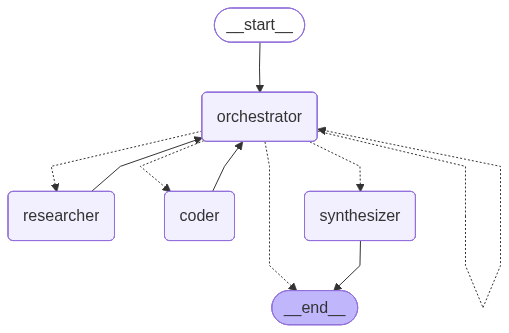

In [5]:
from IPython.display import display, Image

# --- Graph ---
workflow = StateGraph(HierarchicalState)
workflow.add_node("orchestrator", orchestrator_node)
workflow.add_node("researcher", lambda state: worker_node(state, "Researcher", researcher_agent))
workflow.add_node("coder", lambda state: worker_node(state, "Coder", coder_agent))
workflow.add_node("synthesizer", lambda state: synthesize_node(state, synthesizer_agent))

workflow.set_entry_point("orchestrator")


def router(state: HierarchicalState) -> Literal["researcher", "coder", "synthesizer", END, "orchestrator"]:
    if state["status"] == "call_researcher":
        return "researcher"
    if state["status"] == "call_coder":
        return "coder"
    if state["status"] == "synthesizing":
        return "synthesizer"
    if state["status"] == "done":
        return END
    return "orchestrator"


workflow.add_conditional_edges("orchestrator", router)
workflow.add_edge("researcher", "orchestrator")
workflow.add_edge("coder", "orchestrator")
workflow.add_edge("synthesizer", END)

app = workflow.compile()

display(Image(app.get_graph().draw_mermaid_png()))

## ▶️ Demo

Invoke the system with a single `HumanMessage`, then print the full message history, worker outputs, and final answer.

In [6]:
result = app.invoke(
    {
        "messages": [
            HumanMessage(
                content="Search for the latest addition to Python's standard library and summarize its features. Then write a sample code snippet demonstrating its usage."
            )
        ],
        "task": "",
        "worker_outputs": [],
        "status": "delegating",
        "final_output": "",
    }
)

KeyboardInterrupt: 

In [ ]:
print("\n=== HIERARCHICAL MAS — MESSAGE HISTORY ===")
for i, msg in enumerate(result["messages"], start=1):
    role = getattr(msg, "type", msg.__class__.__name__)
    name = getattr(msg, "name", None)
    header = f"{i:02d} | {role}" + (f" ({name})" if name else "")
    print(header)
    print("-" * len(header))
    content = (msg.content or "").strip()
    print(content if content else "<empty>")
    print()

print("=== WORKER OUTPUTS ===")
for i, entry in enumerate(result["worker_outputs"], start=1):
    header = f"Step {i:02d}"
    print(header)
    print("-" * len(header))
    print(entry)
    print()

print("=== FINAL OUTPUT ===")
print(result["final_output"])


=== HIERARCHICAL MAS — WORKER TRANSCRIPT ===
Step 01
-------
[Researcher]: The latest addition to Python's standard library in version 3.12 includes several new features and improvements. Here are some highlights:

1. **New Syntax for Type Variables**: Python 3.12 introduces a new syntax for type variables, enhancing static typing capabilities.

2. **Subinterpreters Module**: A new standard library module named `interpreters` is being developed to expose subinterpreters to Python code, allowing for more efficient parallel execution.

3. **Enhanced Error Messages**: Python 3.12 improves error messages, particularly for non-existent attributes, making debugging easier.

4. **Pattern Matching Improvements**: The match statement, introduced in Python 3.10, has been refined with new patterns in Python 3.12, enhancing functional programming capabilities.

5. **Unicode and Zoneinfo Enhancements**: There are improvements in Unicode handling for strings and enhancements to the zoneinfo module.

In [ ]:
from pprint import pprint

pprint(result)

{'final_output': "The latest addition to Python's standard library in version "
                 '3.12 includes several new features and improvements:\n'
                 '\n'
                 '1. **New Syntax for Type Variables**: Enhances static typing '
                 'capabilities.\n'
                 '2. **Subinterpreters Module**: Introduces the `interpreters` '
                 'module for efficient parallel execution.\n'
                 '3. **Enhanced Error Messages**: Improves debugging with '
                 'better error messages for non-existent attributes.\n'
                 '4. **Pattern Matching Improvements**: Refines the match '
                 'statement with new patterns for functional programming.\n'
                 '5. **Unicode and Zoneinfo Enhancements**: Improves Unicode '
                 'handling and the zoneinfo module.\n'
                 '6. **Performance Optimizations**: Includes faster '
                 'list/dict/set comprehensions through inlin

## 💡 Key Takeaways

- The system accepts a flat `HumanMessage` input and preserves all messages.
- Each node is an agent with role-specific tools.
- The router is linear and explicit, making the control flow easy to trace.